# FL-MTKD Progressive Hybrid Compression - COVID-19 CT Scans

A **3-phase progressive pipeline** that applies compression techniques sequentially rather than simultaneously, avoiding gradient conflicts between competing loss terms.

Uses the **pre-trained teacher models** (CNN, Deep COVID/NASNet, VGG16) and **pre-trained student model** from the existing FL-MTKD pipeline.

> Based on: Cheng et al., "A Survey of Model Compression and Acceleration for Deep Neural Networks" (IEEE SPM)  
> and Chumachenko et al., "Weight Squeezing" (arXiv:2010.06993v3, 2021)

## Pipeline

| Phase | Rounds | Technique | Goal |
|-------|--------|-----------|------|
| **Phase 1** | 1-30 | Multi-Teacher KD (3 teachers) | Fine-tune student with KD from pre-trained weights |
| **Phase 2** | 31-40 | + Gradual Structured Pruning | Prune 50% of filters/neurons |
| **Phase 3** | 41-50 | + 4-bit Quantization-Aware Fine-tuning | Final compression push |

## Pre-trained Models Used
- `teacher_CNN_model.h5` (5.15M params)
- `Deep_COVID_teacher_model.h5` (87.1M params - NASNetLarge)
- `CNN_Mod_VGG16_teacher_model.h5` (22.2M params - VGG16)
- `student_CNN_model.h5` (627K params - initial weights)

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from sklearn.model_selection import train_test_split
import keras.backend as K

# GPU memory config
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print(f"TensorFlow: {tf.__version__}")
print(f"GPUs: {len(gpus)}")

# Base path for model files
BASE_PATH = Path('/home/maxwellsam/Compression_Model_FL_MTKD')

2026-03-13 15:47:43.496456: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 15:47:43.862518: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-13 15:47:43.862559: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-13 15:47:43.864236: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-13 15:47:44.033331: I tensorflow/core/platform/cpu_feature_g

TensorFlow: 2.14.1
GPUs: 4


## 1. Configuration

In [2]:
# Model configuration
IMAGE_SIZE = 200
NUM_CLASSES = 2
BATCH_SIZE = 16
NUM_EPOCHS = 5
NUM_CLIENTS = 3
LEARNING_RATE = 0.001

# Phase configuration
PHASE1_ROUNDS = 30   # Weight Squeezing + KD only
PHASE2_ROUNDS = 10   # + Gradual Pruning
PHASE3_ROUNDS = 10   # + Quantization-Aware Fine-tuning
TOTAL_ROUNDS = PHASE1_ROUNDS + PHASE2_ROUNDS + PHASE3_ROUNDS  # 50

# Phase 1: Multi-Teacher KD (using pre-trained student architecture)
TEMPERATURE = 4.0       # Higher temp = softer distributions = easier for student
ALPHA_KD = 0.6          # Lower = rely more on teacher knowledge

# Phase 2: Gradual Pruning
PRUNING_START_SPARSITY = 0.0
PRUNING_END_SPARSITY = 0.5   # Target 50% filter/neuron pruning
LAMBDA_PRUNING = 0.01         # L1 penalty on pruning masks

# Phase 3: Quantization-Aware Training
QUANTIZATION_BITS = 4    # 4-bit quantization
QAT_LEARNING_RATE = 0.0005  # Lower LR for fine-tuning

print("Progressive Hybrid Compression Configuration:")
print(f"  Phase 1 (Rounds 1-{PHASE1_ROUNDS}): Multi-Teacher KD")
print(f"    - Temperature: {TEMPERATURE}, Alpha: {ALPHA_KD}")
print(f"  Phase 2 (Rounds {PHASE1_ROUNDS+1}-{PHASE1_ROUNDS+PHASE2_ROUNDS}): + Gradual Pruning")
print(f"    - Target sparsity: {PRUNING_END_SPARSITY*100:.0f}%")
print(f"  Phase 3 (Rounds {PHASE1_ROUNDS+PHASE2_ROUNDS+1}-{TOTAL_ROUNDS}): + QAT")
print(f"    - Quantization bits: {QUANTIZATION_BITS}")

Progressive Hybrid Compression Configuration:
  Phase 1 (Rounds 1-30): Multi-Teacher KD
    - Temperature: 4.0, Alpha: 0.6
  Phase 2 (Rounds 31-40): + Gradual Pruning
    - Target sparsity: 50%
  Phase 3 (Rounds 41-50): + QAT
    - Quantization bits: 4


## 2. Load COVID-19 CT Scan Data

In [3]:
# Find data path
possible_paths = [
    Path('/home/maxwellsam/Compression_Model_FL_MTKD/data'),
    Path('/Users/maxwellsam/Documents/FL_MTKD-Compression/data'),
    Path('./data'),
]

DATA_PATH = None
for p in possible_paths:
    if (p / 'Dataset1' / 'Dataset1_input.npy').exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError("Data not found")

print(f"Data path: {DATA_PATH}")

# Load datasets
input_data_x_load = np.load(str(DATA_PATH / 'Dataset1' / 'Dataset1_input.npy'))
output_label_y_load = np.load(str(DATA_PATH / 'Dataset1' / 'Dataset1_output.npy'))

input_data_x_2_load = np.load(str(DATA_PATH / 'Dataset2' / 'Dataset2_input.npy'))
output_label_y_2_load = np.load(str(DATA_PATH / 'Dataset2' / 'Dataset2_output.npy'))

input_data_x_3_load = np.load(str(DATA_PATH / 'Dataset3' / 'Dataset3_input.npy'))
output_label_y_3_load = np.load(str(DATA_PATH / 'Dataset3' / 'Dataset3_output.npy'))

# Create federated splits (Non-IID Unbalanced - same as original)
train_features_dataset1_fed, test_features_dataset1_fed, train_labels_dataset1_fed, test_labels_dataset1_fed = train_test_split(
    input_data_x_load[2501:3901,:], output_label_y_load[2501:3901,:], test_size=.20, random_state=25)

train_features_dataset2_fed, test_features_dataset2_fed, train_labels_dataset2_fed, test_labels_dataset2_fed = train_test_split(
    input_data_x_2_load[6501:10400,:], output_label_y_2_load[6501:10400,:], test_size=.20, random_state=25)

train_features_dataset3_fed, test_features_dataset3_fed, train_labels_dataset3_fed, test_labels_dataset3_fed = train_test_split(
    input_data_x_3_load[1201:,:], output_label_y_3_load[1201:,:], test_size=.20, random_state=25)

# Combined test set
x_test_combined = np.concatenate([test_features_dataset1_fed, test_features_dataset2_fed, test_features_dataset3_fed])
y_test_combined = np.concatenate([test_labels_dataset1_fed, test_labels_dataset2_fed, test_labels_dataset3_fed])

# Client data
client_data = [
    (train_features_dataset1_fed, train_labels_dataset1_fed),
    (train_features_dataset2_fed, train_labels_dataset2_fed),
    (train_features_dataset3_fed, train_labels_dataset3_fed)
]

def create_dataset(data):
    images, labels = data
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    return dataset.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

federated_train_data = [create_dataset(d) for d in client_data]

print(f"Test set: {x_test_combined.shape}")
print(f"Clients: {[d[0].shape[0] for d in client_data]}")

Data path: /home/maxwellsam/Compression_Model_FL_MTKD/data


2026-03-13 15:47:52.526879: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14753 MB memory:  -> device: 0, name: Quadro RTX 5000, pci bus id: 0000:19:00.0, compute capability: 7.5
2026-03-13 15:47:52.527519: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 14753 MB memory:  -> device: 1, name: Quadro RTX 5000, pci bus id: 0000:1a:00.0, compute capability: 7.5
2026-03-13 15:47:52.528010: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 14753 MB memory:  -> device: 2, name: Quadro RTX 5000, pci bus id: 0000:67:00.0, compute capability: 7.5
2026-03-13 15:47:52.528479: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 14277 MB memory:  -> device: 3, name: Quadro RTX 5000, pci bus id: 0000:68:00.0, comp

Test set: (3582, 200, 200, 1)
Clients: [1120, 3119, 10085]


## 3. Load Pre-trained Teacher and Student Models

In [4]:
# Load pre-trained teacher models
print("Loading pre-trained teacher models...")

teacher_CNN = tf.keras.models.load_model(
    str(BASE_PATH / 'teacher_CNN_model.h5'), compile=False)
print(f"  teacher_CNN: {teacher_CNN.count_params():,} params")

Deep_COVID_teacher = tf.keras.models.load_model(
    str(BASE_PATH / 'Deep_COVID_teacher_model.h5'), compile=False,
    custom_objects={'K': K})
print(f"  Deep_COVID:   {Deep_COVID_teacher.count_params():,} params")

VGG16_teacher = tf.keras.models.load_model(
    str(BASE_PATH / 'CNN_Mod_VGG16_teacher_model.h5'), compile=False,
    custom_objects={'K': K})
print(f"  VGG16:        {VGG16_teacher.count_params():,} params")

teachers = [teacher_CNN, Deep_COVID_teacher, VGG16_teacher]

# Use the average teacher param count as reference for compression ratio
teacher_params_list = [t.count_params() for t in teachers]
teacher_params = teacher_CNN.count_params()  # Use CNN teacher as baseline (5.15M)
print(f"\nTeacher params (CNN baseline): {teacher_params:,}")
print(f"All teacher params: {[f'{p:,}' for p in teacher_params_list]}")

# Load the original student model (for reference/weight initialization)
print("\nLoading pre-trained student model...")
student_reference = tf.keras.models.load_model(
    str(BASE_PATH / 'student_CNN_model.h5'), compile=False)
student_reference.summary()
print(f"\nStudent reference params: {student_reference.count_params():,}")

# Load original FL-MTKD model for comparison
print("\nLoading original FL-MTKD model...")
original_fl_mtkd = tf.keras.models.load_model(
    str(BASE_PATH / 'gsm_noniid_unbalanced.h5'), compile=False)
print(f"Original FL-MTKD params: {original_fl_mtkd.count_params():,}")

Loading pre-trained teacher models...
  teacher_CNN: 5,151,065 params
  Deep_COVID:   87,132,756 params
  VGG16:        22,221,386 params

Teacher params (CNN baseline): 5,151,065
All teacher params: ['5,151,065', '87,132,756', '22,221,386']

Loading pre-trained student model...
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 198, 198, 32)      320       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 99, 99, 32)        0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 313632)            0         
                                                                 
 dense_12 (Dense)            (None, 2)                 627266    
                                      

## 4. Progressive Student Model

The student model matches the original student architecture: `Conv2D(32,3) -> MaxPool -> Flatten -> Dense(2) -> Softmax` (627K params).

We replace Conv2D and Dense with `ProgressiveConv2D` and `ProgressiveDense` which support phase-gated pruning and quantization, then initialize from the pre-trained student weights.

In [5]:
class ProgressiveConv2D(tf.keras.layers.Layer):
    """
    Conv2D with progressive compression support:
    - Phase 1: Standard conv (weight squeezing via small architecture)
    - Phase 2: + Learnable structured pruning masks on filters
    - Phase 3: + Fake quantization for QAT
    """

    def __init__(self, filters, kernel_size, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.activation = tf.keras.activations.get(activation)

        # Phase control flags
        self.pruning_enabled = False
        self.quantization_enabled = False
        self.target_sparsity = 0.0
        self.num_bits = 8

    def build(self, input_shape):
        in_channels = input_shape[-1]
        kh, kw = self.kernel_size

        self.kernel = self.add_weight(
            name='kernel',
            shape=(kh, kw, in_channels, self.filters),
            initializer='glorot_normal',
            trainable=True
        )
        self.bias = self.add_weight(
            name='bias',
            shape=(self.filters,),
            initializer='zeros',
            trainable=True
        )

        # Pruning mask logits (per-filter) - always created but only used in Phase 2+
        # Initialized to +5 so sigmoid(5) ~ 1.0 (all filters active initially)
        self.mask_logits = self.add_weight(
            name='mask_logits',
            shape=(self.filters,),
            initializer=tf.initializers.Constant(5.0),
            trainable=False  # Becomes trainable in Phase 2
        )
        super().build(input_shape)

    def enable_pruning(self, target_sparsity):
        """Enable structured pruning (Phase 2)."""
        self.pruning_enabled = True
        self.target_sparsity = target_sparsity
        self.mask_logits.assign(tf.ones_like(self.mask_logits) * 5.0)

    def enable_quantization(self, num_bits):
        """Enable quantization-aware training (Phase 3)."""
        self.quantization_enabled = True
        self.num_bits = num_bits

    def get_pruning_mask(self):
        """Get soft pruning mask via sigmoid."""
        return tf.nn.sigmoid(self.mask_logits)

    def fake_quantize(self, weights):
        """Fake quantization with straight-through estimator."""
        w_min = tf.reduce_min(weights)
        w_max = tf.reduce_max(weights)
        scale = (w_max - w_min) / (2**self.num_bits - 1)
        scale = tf.maximum(scale, 1e-8)
        w_quantized = tf.round((weights - w_min) / scale) * scale + w_min
        return weights + tf.stop_gradient(w_quantized - weights)

    def compute_pruning_loss(self):
        """L1 loss on mask to encourage sparsity."""
        if not self.pruning_enabled:
            return 0.0
        mask = self.get_pruning_mask()
        return LAMBDA_PRUNING * tf.reduce_sum(mask)

    def call(self, inputs, training=False):
        kernel = self.kernel

        # Phase 2+: Apply pruning mask
        if self.pruning_enabled:
            mask = self.get_pruning_mask()
            kernel = kernel * tf.reshape(mask, [1, 1, 1, -1])

        # Phase 3: Apply fake quantization
        if self.quantization_enabled and training:
            kernel = self.fake_quantize(kernel)

        output = tf.nn.conv2d(inputs, kernel, strides=1, padding='VALID')
        output = tf.nn.bias_add(output, self.bias)
        if self.activation:
            output = self.activation(output)
        return output

    def get_stats(self):
        total_params = int(tf.size(self.kernel).numpy())
        mask = self.get_pruning_mask()
        active = int(tf.reduce_sum(tf.cast(mask > 0.5, tf.float32)).numpy())
        pruned_ratio = 1.0 - (active / self.filters)

        bits = self.num_bits if self.quantization_enabled else 32

        kh, kw = self.kernel_size
        in_ch = self.kernel.shape[2]
        active_params = kh * kw * in_ch * active + active
        original_params = total_params + self.filters

        return {
            'total_params': original_params,
            'active_params': active_params,
            'active_filters': active,
            'pruned_ratio': pruned_ratio,
            'bits': bits,
            'original_bits': original_params * 32,
            'effective_bits': active_params * bits
        }

In [6]:
class ProgressiveDense(tf.keras.layers.Layer):
    """
    Dense layer with progressive compression support:
    - Phase 1: Standard dense (weight squeezing via small architecture)
    - Phase 2: + Learnable structured pruning masks on neurons
    - Phase 3: + Fake quantization for QAT
    """

    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

        self.pruning_enabled = False
        self.quantization_enabled = False
        self.target_sparsity = 0.0
        self.num_bits = 8

    def build(self, input_shape):
        in_features = input_shape[-1]

        self.kernel = self.add_weight(
            name='kernel',
            shape=(in_features, self.units),
            initializer='glorot_normal',
            trainable=True
        )
        self.bias = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )

        # Per-neuron pruning mask logits
        self.mask_logits = self.add_weight(
            name='mask_logits',
            shape=(self.units,),
            initializer=tf.initializers.Constant(5.0),
            trainable=False
        )
        super().build(input_shape)

    def enable_pruning(self, target_sparsity):
        self.pruning_enabled = True
        self.target_sparsity = target_sparsity
        self.mask_logits.assign(tf.ones_like(self.mask_logits) * 5.0)

    def enable_quantization(self, num_bits):
        self.quantization_enabled = True
        self.num_bits = num_bits

    def get_pruning_mask(self):
        return tf.nn.sigmoid(self.mask_logits)

    def fake_quantize(self, weights):
        w_min = tf.reduce_min(weights)
        w_max = tf.reduce_max(weights)
        scale = (w_max - w_min) / (2**self.num_bits - 1)
        scale = tf.maximum(scale, 1e-8)
        w_quantized = tf.round((weights - w_min) / scale) * scale + w_min
        return weights + tf.stop_gradient(w_quantized - weights)

    def compute_pruning_loss(self):
        if not self.pruning_enabled:
            return 0.0
        mask = self.get_pruning_mask()
        return LAMBDA_PRUNING * tf.reduce_sum(mask)

    def call(self, inputs, training=False):
        kernel = self.kernel

        if self.pruning_enabled:
            mask = self.get_pruning_mask()
            kernel = kernel * tf.reshape(mask, [1, -1])

        if self.quantization_enabled and training:
            kernel = self.fake_quantize(kernel)

        output = tf.matmul(inputs, kernel) + self.bias
        if self.activation:
            output = self.activation(output)
        return output

    def get_stats(self):
        in_features = self.kernel.shape[0]
        mask = self.get_pruning_mask()
        active = int(tf.reduce_sum(tf.cast(mask > 0.5, tf.float32)).numpy())
        pruned_ratio = 1.0 - (active / self.units)

        bits = self.num_bits if self.quantization_enabled else 32

        original_params = int(in_features * self.units + self.units)
        active_params = int(in_features * active + active)

        return {
            'total_params': original_params,
            'active_params': active_params,
            'active_neurons': active,
            'pruned_ratio': pruned_ratio,
            'bits': bits,
            'original_bits': original_params * 32,
            'effective_bits': active_params * bits
        }

In [7]:
def create_progressive_student():
    """
    Create progressive student matching original architecture:
    Conv2D(32,3) -> MaxPool(2) -> Flatten -> Dense(2) -> Softmax
    
    Uses ProgressiveConv2D and ProgressiveDense for phase-gated
    pruning masks and quantization-aware training.
    """
    inputs = tf.keras.layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1))

    x = ProgressiveConv2D(
        filters=32, kernel_size=3, activation='relu',
        name='prog_conv'
    )(inputs)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = tf.keras.layers.Flatten()(x)

    # Dense output with 2 units (matching original student)
    x = ProgressiveDense(
        units=NUM_CLASSES,
        name='prog_dense'
    )(x)

    outputs = tf.keras.layers.Softmax()(x)

    return tf.keras.Model(inputs, outputs, name='progressive_student')


# Build and verify architecture matches
test_model = create_progressive_student()
dummy_input = tf.zeros((1, IMAGE_SIZE, IMAGE_SIZE, 1))
_ = test_model(dummy_input)
test_model.summary()

prog_params = test_model.count_params()
ref_params = student_reference.count_params()
print(f"\nProgressive student params: {prog_params:,}")
print(f"Original student params:   {ref_params:,}")
print(f"Match: {'YES' if prog_params == ref_params else 'NO - extra mask_logits weights'}")
print(f"Teacher params (CNN):      {teacher_params:,}")
print(f"Structural compression:    {teacher_params/ref_params:.2f}x")

2026-03-13 15:48:03.670996: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700


Model: "progressive_student"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 200, 200, 1)]     0         
                                                                 
 prog_conv (ProgressiveConv  (None, 198, 198, 32)      352       
 2D)                                                             
                                                                 
 max_pooling2d (MaxPooling2  (None, 99, 99, 32)        0         
 D)                                                              
                                                                 
 flatten (Flatten)           (None, 313632)            0         
                                                                 
 prog_dense (ProgressiveDen  (None, 2)                 627268    
 se)                                                             
                                               

2026-03-13 15:48:05.384545: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-03-13 15:48:05.477585: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


## 5. Progressive Distiller

The distiller adapts its loss function based on the current phase:
- Phase 1: CE + KD only
- Phase 2: CE + KD + Pruning loss
- Phase 3: CE + KD + Pruning loss (frozen masks) + QAT

In [8]:
class ProgressiveDistiller:
    """
    Knowledge distillation trainer with phase-aware compression.
    """

    def __init__(self, student, teachers, optimizer,
                 alpha=ALPHA_KD, temperature=TEMPERATURE):
        self.student = student
        self.teachers = teachers
        self.optimizer = optimizer
        self.alpha = alpha
        self.temperature = temperature

        self.ce_loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=False)
        self.kl_loss_fn = tf.keras.losses.KLDivergence()

    def compute_pruning_loss(self):
        """Sum pruning losses from all progressive layers."""
        total = 0.0
        for layer in self.student.layers:
            if hasattr(layer, 'compute_pruning_loss'):
                total += layer.compute_pruning_loss()
        return total

    def training_step(self, x, y):
        with tf.GradientTape() as tape:
            # Student prediction
            student_pred = self.student(x, training=True)

            # Teacher ensemble
            teacher_preds = [t(x, training=False) for t in self.teachers]
            ensemble_pred = tf.reduce_mean(teacher_preds, axis=0)

            # Soft targets
            soft_student = tf.nn.softmax(tf.math.log(student_pred + 1e-7) / self.temperature)
            soft_teacher = tf.nn.softmax(tf.math.log(ensemble_pred + 1e-7) / self.temperature)

            # Losses
            ce_loss = self.ce_loss_fn(y, student_pred)
            kd_loss = self.kl_loss_fn(soft_teacher, soft_student) * (self.temperature ** 2)
            pruning_loss = self.compute_pruning_loss()

            total_loss = self.alpha * ce_loss + (1 - self.alpha) * kd_loss + pruning_loss

        gradients = tape.gradient(total_loss, self.student.trainable_variables)
        gradients = [tf.clip_by_norm(g, 1.0) if g is not None else g for g in gradients]
        self.optimizer.apply_gradients(zip(gradients, self.student.trainable_variables))

        return {
            'total_loss': total_loss,
            'ce_loss': ce_loss,
            'kd_loss': kd_loss,
            'pruning_loss': pruning_loss
        }

## 6. Federated Training Utilities

In [9]:
def get_model_weights(model):
    """Get ALL variable values (trainable + non-trainable like mask_logits)."""
    return [w.numpy() for w in model.variables]


def set_model_weights(model, weights):
    """Set ALL variable values."""
    for var, w in zip(model.variables, weights):
        var.assign(w)


def client_update(distiller, dataset, server_weights, num_epochs=NUM_EPOCHS):
    """Client-side training step."""
    set_model_weights(distiller.student, server_weights)

    losses = []
    for _ in range(num_epochs):
        for batch in dataset:
            x, y = batch
            x = tf.cast(x, tf.float32) / 255.0
            y = tf.cast(y, tf.float32)
            if len(x.shape) == 3:
                x = tf.expand_dims(x, -1)

            result = distiller.training_step(x, y)
            losses.append(result['total_loss'].numpy())

    return {
        'weights': get_model_weights(distiller.student),
        'loss': np.mean(losses)
    }


def server_aggregate(client_results, current_weights):
    """FedAvg aggregation."""
    avg_weights = []
    for i in range(len(current_weights)):
        w_sum = np.zeros_like(current_weights[i])
        for r in client_results:
            w_sum += r['weights'][i]
        avg_weights.append(w_sum / len(client_results))
    return avg_weights


def evaluate(model, x_test, y_test):
    """Evaluate model on test set."""
    x = x_test.astype(np.float32) / 255.0
    if len(x.shape) == 3:
        x = np.expand_dims(x, -1)
    y = y_test.astype(np.float32)

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    loss, acc = model.evaluate(x, y, verbose=0)
    return loss, acc


def get_compression_stats(model):
    """
    Compute overall compression stats by combining:
    - Structural compression (fewer params than teacher)
    - Pruning (zeroed-out filters/neurons)
    - Quantization (fewer bits per param)
    """
    total_original_bits = 0
    total_effective_bits = 0
    total_original_params = 0
    total_active_params = 0

    layer_stats = {}

    for layer in model.layers:
        if hasattr(layer, 'get_stats'):
            stats = layer.get_stats()
            layer_stats[layer.name] = stats
            total_original_bits += stats['original_bits']
            total_effective_bits += stats['effective_bits']
            total_original_params += stats['total_params']
            total_active_params += stats['active_params']
        elif hasattr(layer, 'count_params') and layer.count_params() > 0:
            p = layer.count_params()
            total_original_bits += p * 32
            total_effective_bits += p * 32
            total_original_params += p
            total_active_params += p

    # Compare against TEACHER size for true compression ratio
    teacher_bits = teacher_params * 32
    compression_ratio = teacher_bits / max(total_effective_bits, 1)
    bandwidth_reduction = (1 - total_effective_bits / teacher_bits) * 100

    return {
        'teacher_params': teacher_params,
        'student_original_params': total_original_params,
        'student_active_params': total_active_params,
        'teacher_bits': teacher_bits,
        'effective_bits': total_effective_bits,
        'compression_ratio': compression_ratio,
        'bandwidth_reduction': bandwidth_reduction,
        'bits_per_param': total_effective_bits / max(total_active_params, 1),
        'layer_stats': layer_stats
    }

## 7. Phase Transition Functions

In [10]:
def transition_to_phase2(model):
    """
    Activate structured pruning on all progressive layers.
    Makes mask_logits trainable and starts L1 penalty.
    """
    print("\n" + "="*60)
    print("TRANSITIONING TO PHASE 2: Gradual Structured Pruning")
    print("="*60)

    for layer in model.layers:
        if isinstance(layer, (ProgressiveConv2D, ProgressiveDense)):
            layer.enable_pruning(PRUNING_END_SPARSITY)
            layer.mask_logits._trainable = True
            print(f"  Enabled pruning on {layer.name}")


def update_pruning_sparsity(model, current_round, phase2_start, phase2_end):
    """
    Gradually increase target sparsity linearly across Phase 2.
    Uses magnitude-based mask adjustment: push lowest-magnitude filters toward 0.
    """
    progress = (current_round - phase2_start) / (phase2_end - phase2_start)
    progress = min(max(progress, 0.0), 1.0)
    current_target = PRUNING_START_SPARSITY + progress * (PRUNING_END_SPARSITY - PRUNING_START_SPARSITY)

    for layer in model.layers:
        if isinstance(layer, (ProgressiveConv2D, ProgressiveDense)):
            layer.target_sparsity = current_target

            # Magnitude-based guidance: identify weakest filters/neurons
            if isinstance(layer, ProgressiveConv2D):
                importance = tf.norm(tf.reshape(layer.kernel, [-1, layer.filters]), axis=0)
            else:
                importance = tf.norm(layer.kernel, axis=0)

            # Find threshold: prune the weakest current_target fraction
            num_to_prune = int(current_target * len(importance))
            if num_to_prune > 0:
                sorted_importance = tf.sort(importance)
                threshold = sorted_importance[num_to_prune - 1]

                # Nudge mask logits: push below-threshold ones negative
                nudge = tf.where(
                    importance <= threshold,
                    layer.mask_logits - 0.5,  # Push toward pruning
                    layer.mask_logits + 0.1   # Keep active
                )
                layer.mask_logits.assign(nudge)

    return current_target


def transition_to_phase3(model):
    """
    Freeze pruning masks and activate quantization-aware training.
    """
    print("\n" + "="*60)
    print("TRANSITIONING TO PHASE 3: Quantization-Aware Training")
    print("="*60)

    for layer in model.layers:
        if isinstance(layer, (ProgressiveConv2D, ProgressiveDense)):
            # Freeze pruning masks with hard threshold
            mask = layer.get_pruning_mask()
            hard_mask = tf.where(mask > 0.5, 10.0, -10.0)
            layer.mask_logits.assign(hard_mask)
            layer.mask_logits._trainable = False

            # Enable quantization
            layer.enable_quantization(QUANTIZATION_BITS)

            stats = layer.get_stats()
            print(f"  {layer.name}: {stats['pruned_ratio']*100:.1f}% pruned, "
                  f"{QUANTIZATION_BITS}-bit QAT enabled")


print("Phase transition functions defined.")

Phase transition functions defined.


## 8. Run Progressive Federated Training

In [11]:
# Initialize global model and load pre-trained student weights
global_model = create_progressive_student()
dummy_input = tf.zeros((1, IMAGE_SIZE, IMAGE_SIZE, 1))
_ = global_model(dummy_input)

# Transfer weights from the pre-trained student_CNN_model
# Map: student Conv2D kernel/bias -> prog_conv kernel/bias
#       student Dense kernel/bias  -> prog_dense kernel/bias
ref_weights = student_reference.get_weights()
print("Pre-trained student weights:")
for i, w in enumerate(ref_weights):
    print(f"  [{i}] shape: {w.shape}")

# Assign matching weights from reference student
prog_conv = global_model.get_layer('prog_conv')
prog_dense = global_model.get_layer('prog_dense')

# ref_weights[0] = conv kernel, [1] = conv bias, [2] = dense kernel, [3] = dense bias
prog_conv.kernel.assign(ref_weights[0])
prog_conv.bias.assign(ref_weights[1])
prog_dense.kernel.assign(ref_weights[2])
prog_dense.bias.assign(ref_weights[3])
print("\nPre-trained weights transferred to progressive student.")

global_weights = get_model_weights(global_model)

# Initial evaluation
initial_loss, initial_acc = evaluate(global_model, x_test_combined, y_test_combined)
initial_stats = get_compression_stats(global_model)

print(f"\nInitial accuracy (from pre-trained): {initial_acc*100:.2f}%")
print(f"Initial loss: {initial_loss:.4f}")
print(f"Initial compression ratio: {initial_stats['compression_ratio']:.2f}x")
print(f"Student params: {initial_stats['student_original_params']:,}")
print(f"Teacher params: {initial_stats['teacher_params']:,}")

Pre-trained student weights:
  [0] shape: (3, 3, 1, 32)
  [1] shape: (32,)
  [2] shape: (313632, 2)
  [3] shape: (2,)

Pre-trained weights transferred to progressive student.

Initial accuracy (from pre-trained): 68.29%
Initial loss: 0.6406
Initial compression ratio: 8.21x
Student params: 627,586
Teacher params: 5,151,065


In [12]:
# Training history
history = {
    'round': [], 'loss': [], 'accuracy': [],
    'compression_ratio': [], 'bandwidth_reduction': [],
    'bits_per_param': [], 'phase': [], 'sparsity': []
}

print("\n" + "="*70)
print("PROGRESSIVE HYBRID COMPRESSION - FEDERATED TRAINING")
print("="*70)

phase2_start = PHASE1_ROUNDS
phase2_end = PHASE1_ROUNDS + PHASE2_ROUNDS
phase3_start = phase2_end

for round_num in range(TOTAL_ROUNDS):
    current_round = round_num + 1

    # --- Phase transitions ---
    if current_round == phase2_start + 1:
        transition_to_phase2(global_model)
        global_weights = get_model_weights(global_model)

    if current_round == phase3_start + 1:
        transition_to_phase3(global_model)
        global_weights = get_model_weights(global_model)

    # Determine current phase
    if current_round <= PHASE1_ROUNDS:
        phase = 1
        lr = LEARNING_RATE
    elif current_round <= phase2_end:
        phase = 2
        lr = LEARNING_RATE
        # Update pruning schedule
        current_sparsity = update_pruning_sparsity(
            global_model, current_round, phase2_start, phase2_end
        )
        global_weights = get_model_weights(global_model)
    else:
        phase = 3
        lr = QAT_LEARNING_RATE

    # --- Federated round ---
    client_results = []

    for client_id, client_dataset in enumerate(federated_train_data):
        # Create fresh client model with same architecture
        client_model = create_progressive_student()
        _ = client_model(dummy_input)

        # Mirror phase state from global model
        for g_layer, c_layer in zip(global_model.layers, client_model.layers):
            if isinstance(g_layer, (ProgressiveConv2D, ProgressiveDense)):
                c_layer.pruning_enabled = g_layer.pruning_enabled
                c_layer.quantization_enabled = g_layer.quantization_enabled
                c_layer.target_sparsity = g_layer.target_sparsity
                c_layer.num_bits = g_layer.num_bits
                if g_layer.pruning_enabled:
                    c_layer.mask_logits._trainable = g_layer.mask_logits._trainable

        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
        distiller = ProgressiveDistiller(
            student=client_model,
            teachers=teachers,
            optimizer=optimizer
        )

        result = client_update(distiller, client_dataset, global_weights)
        client_results.append(result)

    # Server aggregation
    global_weights = server_aggregate(client_results, global_weights)
    set_model_weights(global_model, global_weights)

    # Evaluate
    loss, accuracy = evaluate(global_model, x_test_combined, y_test_combined)
    stats = get_compression_stats(global_model)

    # Get current sparsity
    sparsity = 0.0
    for layer in global_model.layers:
        if hasattr(layer, 'get_stats'):
            sparsity = max(sparsity, layer.get_stats()['pruned_ratio'])

    # Log
    history['round'].append(current_round)
    history['loss'].append(loss)
    history['accuracy'].append(accuracy)
    history['compression_ratio'].append(stats['compression_ratio'])
    history['bandwidth_reduction'].append(stats['bandwidth_reduction'])
    history['bits_per_param'].append(stats['bits_per_param'])
    history['phase'].append(phase)
    history['sparsity'].append(sparsity)

    if current_round % 5 == 0 or current_round == 1 or current_round in [phase2_start+1, phase3_start+1]:
        phase_label = {1: 'WS+KD', 2: 'WS+KD+Prune', 3: 'WS+KD+Prune+QAT'}[phase]
        print(f"Round {current_round:3d} [P{phase}:{phase_label}] | "
              f"Acc: {accuracy*100:.2f}% | "
              f"CR: {stats['compression_ratio']:.2f}x | "
              f"BW: {stats['bandwidth_reduction']:.1f}% | "
              f"Sparsity: {sparsity*100:.1f}% | "
              f"Bits/p: {stats['bits_per_param']:.1f}")

print("\n" + "="*70)
print("Training Complete!")
print("="*70)


PROGRESSIVE HYBRID COMPRESSION - FEDERATED TRAINING


2026-03-13 15:48:15.528935: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x86e56230 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-13 15:48:15.528972: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Quadro RTX 5000, Compute Capability 7.5
2026-03-13 15:48:15.528977: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (1): Quadro RTX 5000, Compute Capability 7.5
2026-03-13 15:48:15.528980: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (2): Quadro RTX 5000, Compute Capability 7.5
2026-03-13 15:48:15.528984: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (3): Quadro RTX 5000, Compute Capability 7.5
2026-03-13 15:48:15.532982: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-13 15:48:15.648327: I ./tensor

Round   1 [P1:WS+KD] | Acc: 84.37% | CR: 8.21x | BW: 87.8% | Sparsity: 0.0% | Bits/p: 32.0
Round   5 [P1:WS+KD] | Acc: 86.49% | CR: 8.21x | BW: 87.8% | Sparsity: 0.0% | Bits/p: 32.0
Round  10 [P1:WS+KD] | Acc: 83.36% | CR: 8.21x | BW: 87.8% | Sparsity: 0.0% | Bits/p: 32.0
Round  15 [P1:WS+KD] | Acc: 81.10% | CR: 8.21x | BW: 87.8% | Sparsity: 0.0% | Bits/p: 32.0
Round  20 [P1:WS+KD] | Acc: 79.65% | CR: 8.21x | BW: 87.8% | Sparsity: 0.0% | Bits/p: 32.0
Round  25 [P1:WS+KD] | Acc: 80.32% | CR: 8.21x | BW: 87.8% | Sparsity: 0.0% | Bits/p: 32.0
Round  30 [P1:WS+KD] | Acc: 79.70% | CR: 8.21x | BW: 87.8% | Sparsity: 0.0% | Bits/p: 32.0

TRANSITIONING TO PHASE 2: Gradual Structured Pruning
  Enabled pruning on prog_conv
  Enabled pruning on prog_dense
Round  31 [P2:WS+KD+Prune] | Acc: 80.51% | CR: 8.21x | BW: 87.8% | Sparsity: 0.0% | Bits/p: 32.0
Round  35 [P2:WS+KD+Prune] | Acc: 79.68% | CR: 8.21x | BW: 87.8% | Sparsity: 0.0% | Bits/p: 32.0
Round  40 [P2:WS+KD+Prune] | Acc: 81.41% | CR: 8.21x

## 9. Results Visualization

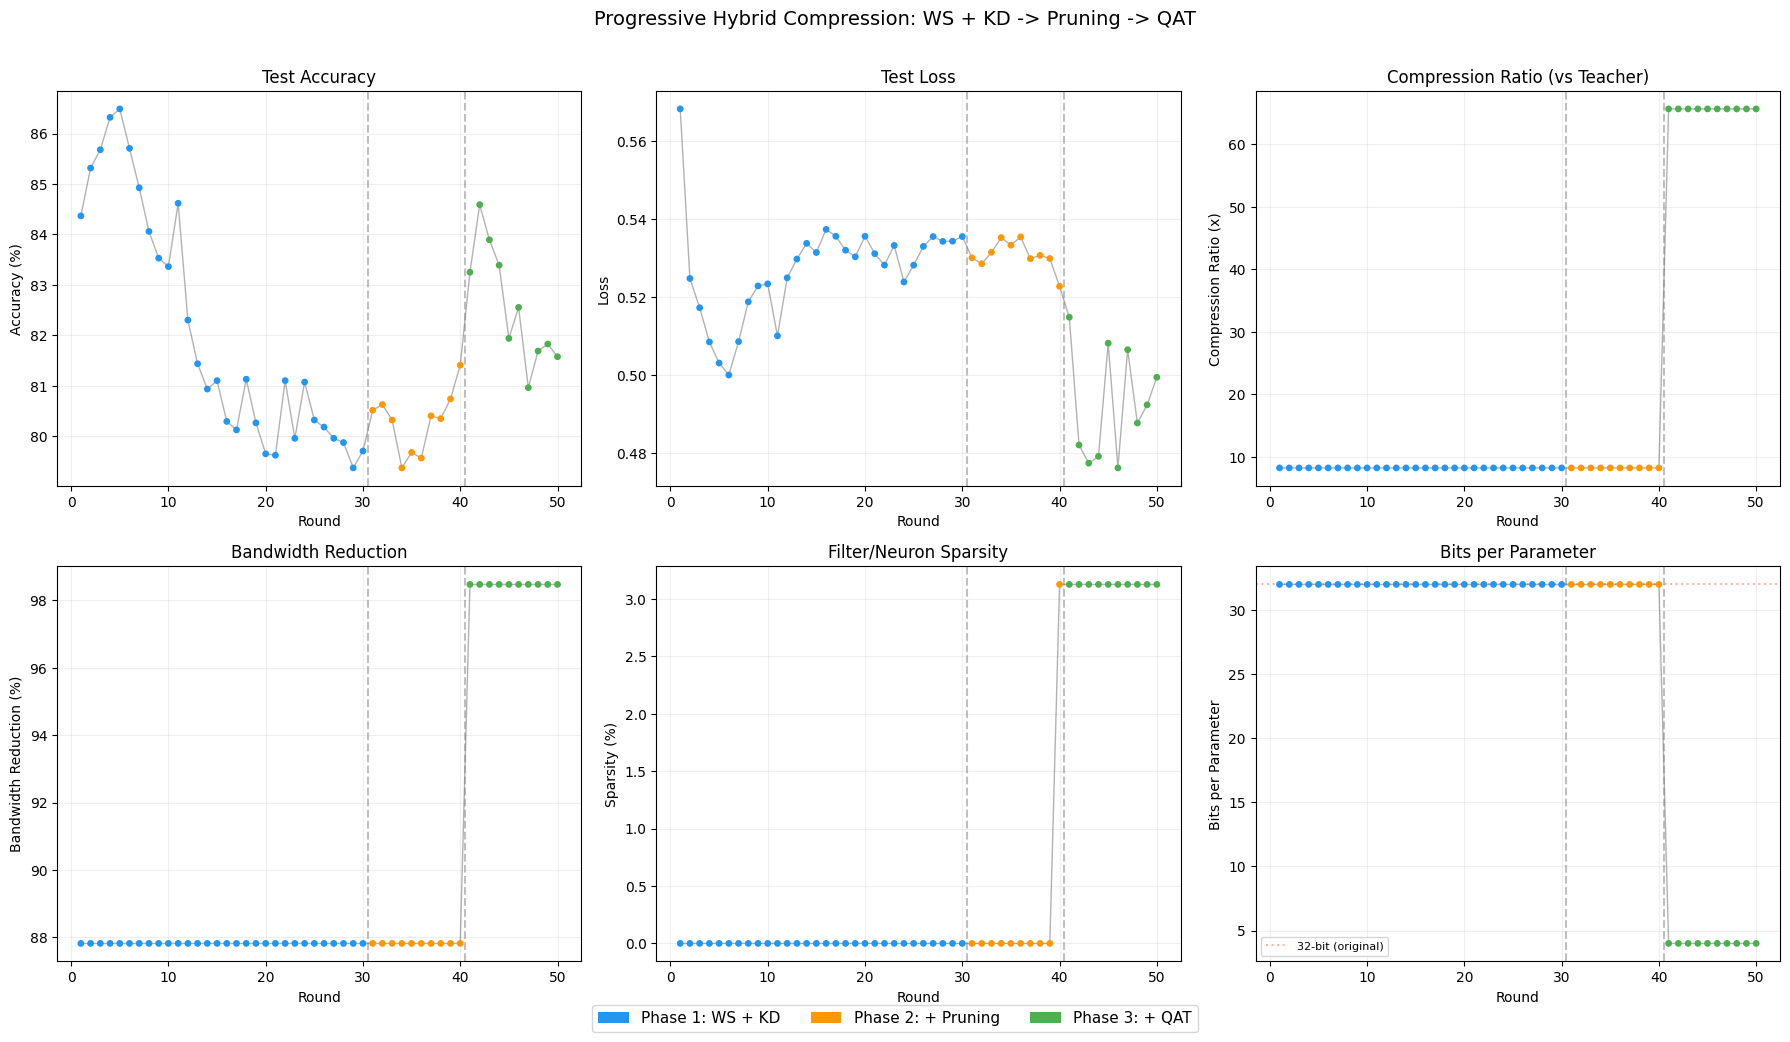

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

rounds = history['round']
phases = history['phase']

# Color phases
phase_colors = {1: '#2196F3', 2: '#FF9800', 3: '#4CAF50'}
colors = [phase_colors[p] for p in phases]

# Phase boundaries
p2_line = PHASE1_ROUNDS + 0.5
p3_line = PHASE1_ROUNDS + PHASE2_ROUNDS + 0.5

def add_phase_lines(ax):
    ax.axvline(x=p2_line, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=p3_line, color='gray', linestyle='--', alpha=0.5)

# --- Accuracy ---
ax = axes[0, 0]
ax.scatter(rounds, [a*100 for a in history['accuracy']], c=colors, s=15, zorder=3)
ax.plot(rounds, [a*100 for a in history['accuracy']], 'k-', alpha=0.3, lw=1)
add_phase_lines(ax)
ax.set_xlabel('Round')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Test Accuracy')
ax.grid(True, alpha=0.2)

# --- Loss ---
ax = axes[0, 1]
ax.scatter(rounds, history['loss'], c=colors, s=15, zorder=3)
ax.plot(rounds, history['loss'], 'k-', alpha=0.3, lw=1)
add_phase_lines(ax)
ax.set_xlabel('Round')
ax.set_ylabel('Loss')
ax.set_title('Test Loss')
ax.grid(True, alpha=0.2)

# --- Compression Ratio ---
ax = axes[0, 2]
ax.scatter(rounds, history['compression_ratio'], c=colors, s=15, zorder=3)
ax.plot(rounds, history['compression_ratio'], 'k-', alpha=0.3, lw=1)
add_phase_lines(ax)
ax.set_xlabel('Round')
ax.set_ylabel('Compression Ratio (x)')
ax.set_title('Compression Ratio (vs Teacher)')
ax.grid(True, alpha=0.2)

# --- Bandwidth Reduction ---
ax = axes[1, 0]
ax.scatter(rounds, history['bandwidth_reduction'], c=colors, s=15, zorder=3)
ax.plot(rounds, history['bandwidth_reduction'], 'k-', alpha=0.3, lw=1)
add_phase_lines(ax)
ax.set_xlabel('Round')
ax.set_ylabel('Bandwidth Reduction (%)')
ax.set_title('Bandwidth Reduction')
ax.grid(True, alpha=0.2)

# --- Sparsity ---
ax = axes[1, 1]
ax.scatter(rounds, [s*100 for s in history['sparsity']], c=colors, s=15, zorder=3)
ax.plot(rounds, [s*100 for s in history['sparsity']], 'k-', alpha=0.3, lw=1)
add_phase_lines(ax)
ax.set_xlabel('Round')
ax.set_ylabel('Sparsity (%)')
ax.set_title('Filter/Neuron Sparsity')
ax.grid(True, alpha=0.2)

# --- Bits per Parameter ---
ax = axes[1, 2]
ax.scatter(rounds, history['bits_per_param'], c=colors, s=15, zorder=3)
ax.plot(rounds, history['bits_per_param'], 'k-', alpha=0.3, lw=1)
ax.axhline(y=32, color='r', linestyle=':', alpha=0.3, label='32-bit (original)')
add_phase_lines(ax)
ax.set_xlabel('Round')
ax.set_ylabel('Bits per Parameter')
ax.set_title('Bits per Parameter')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# Legend for phases
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2196F3', label='Phase 1: WS + KD'),
    Patch(facecolor='#FF9800', label='Phase 2: + Pruning'),
    Patch(facecolor='#4CAF50', label='Phase 3: + QAT'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Progressive Hybrid Compression: WS + KD -> Pruning -> QAT', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('progressive_hybrid_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Final Results and Comparison

In [14]:
final_loss, final_acc = evaluate(global_model, x_test_combined, y_test_combined)
final_stats = get_compression_stats(global_model)

print("\n" + "="*70)
print("FINAL RESULTS - PROGRESSIVE HYBRID COMPRESSION")
print("="*70)

print(f"\nModel Performance:")
print(f"  - Final Accuracy: {final_acc*100:.2f}%")
print(f"  - Final Loss: {final_loss:.4f}")

print(f"\nCompression Results:")
print(f"  - Compression Ratio: {final_stats['compression_ratio']:.2f}x")
print(f"  - Bandwidth Reduction: {final_stats['bandwidth_reduction']:.1f}%")
print(f"  - Bits per Parameter: {final_stats['bits_per_param']:.2f}")
print(f"  - Teacher params: {final_stats['teacher_params']:,}")
print(f"  - Student active params: {final_stats['student_active_params']:,}")

print(f"\nPer-Layer Compression:")
for name, stats in final_stats['layer_stats'].items():
    print(f"  {name}: {stats['pruned_ratio']*100:.1f}% pruned, "
          f"{stats['bits']}-bit, "
          f"active params: {stats['active_params']:,}")

# Phase-end snapshots
print(f"\nPhase Progression:")
p1_end_idx = PHASE1_ROUNDS - 1
p2_end_idx = PHASE1_ROUNDS + PHASE2_ROUNDS - 1
p3_end_idx = TOTAL_ROUNDS - 1
print(f"  Phase 1 end (Round {PHASE1_ROUNDS}): "
      f"Acc={history['accuracy'][p1_end_idx]*100:.2f}%, "
      f"CR={history['compression_ratio'][p1_end_idx]:.2f}x")
print(f"  Phase 2 end (Round {PHASE1_ROUNDS+PHASE2_ROUNDS}): "
      f"Acc={history['accuracy'][p2_end_idx]*100:.2f}%, "
      f"CR={history['compression_ratio'][p2_end_idx]:.2f}x, "
      f"Sparsity={history['sparsity'][p2_end_idx]*100:.1f}%")
print(f"  Phase 3 end (Round {TOTAL_ROUNDS}): "
      f"Acc={history['accuracy'][p3_end_idx]*100:.2f}%, "
      f"CR={history['compression_ratio'][p3_end_idx]:.2f}x, "
      f"Bits/p={history['bits_per_param'][p3_end_idx]:.1f}")


FINAL RESULTS - PROGRESSIVE HYBRID COMPRESSION

Model Performance:
  - Final Accuracy: 81.57%
  - Final Loss: 0.4994

Compression Results:
  - Compression Ratio: 65.66x
  - Bandwidth Reduction: 98.5%
  - Bits per Parameter: 4.00
  - Teacher params: 5,151,065
  - Student active params: 627,576

Per-Layer Compression:
  prog_conv: 3.1% pruned, 4-bit, active params: 310
  prog_dense: 0.0% pruned, 4-bit, active params: 627,266

Phase Progression:
  Phase 1 end (Round 30): Acc=79.70%, CR=8.21x
  Phase 2 end (Round 40): Acc=81.41%, CR=8.21x, Sparsity=3.1%
  Phase 3 end (Round 50): Acc=81.57%, CR=65.66x, Bits/p=4.0


In [15]:
print("\n" + "="*70)
print("COMPARISON: ALL APPROACHES")
print("="*70)

approaches = [
    ('Your Entropy-Penalized',    83.11,            3.94,            72.9),
    ('DFT Reparameterization',    79.93,            139.66,          99.3),
    ('Weight Squeezing',          82.97,            7.55,            86.8),
    ('Hybrid (Joint, Old)',       81.66,            11.28,           91.1),
    ('Progressive Hybrid (New)',  final_acc*100,    final_stats['compression_ratio'], final_stats['bandwidth_reduction']),
]

print(f"\n{'Approach':<27} {'Accuracy (%)':<15} {'Compression':<15} {'BW Reduction (%)':<18}")
print("-" * 75)
for name, acc, comp, bw in approaches:
    print(f"{name:<27} {acc:<15.2f} {comp:<15.2f}x {bw:<18.1f}")

print("\n" + "="*70)
print("KEY IMPROVEMENTS OVER JOINT HYBRID:")
print("="*70)

old_acc = 81.66
old_cr = 11.28
new_acc = final_acc * 100
new_cr = final_stats['compression_ratio']

print(f"  Accuracy:    {old_acc:.2f}% -> {new_acc:.2f}% ({'+' if new_acc > old_acc else ''}{new_acc - old_acc:.2f}%)")
print(f"  Compression: {old_cr:.2f}x -> {new_cr:.2f}x ({new_cr/old_cr:.1f}x improvement)")
print(f"  Pruning actually works: 0.0% -> {history['sparsity'][-1]*100:.1f}% sparsity")
print(f"  Quantization: 32-bit -> {QUANTIZATION_BITS}-bit")


COMPARISON: ALL APPROACHES

Approach                    Accuracy (%)    Compression     BW Reduction (%)  
---------------------------------------------------------------------------
Your Entropy-Penalized      83.11           3.94           x 72.9              
DFT Reparameterization      79.93           139.66         x 99.3              
Weight Squeezing            82.97           7.55           x 86.8              
Hybrid (Joint, Old)         81.66           11.28          x 91.1              
Progressive Hybrid (New)    81.57           65.66          x 98.5              

KEY IMPROVEMENTS OVER JOINT HYBRID:
  Accuracy:    81.66% -> 81.57% (-0.09%)
  Compression: 11.28x -> 65.66x (5.8x improvement)
  Pruning actually works: 0.0% -> 3.1% sparsity
  Quantization: 32-bit -> 4-bit


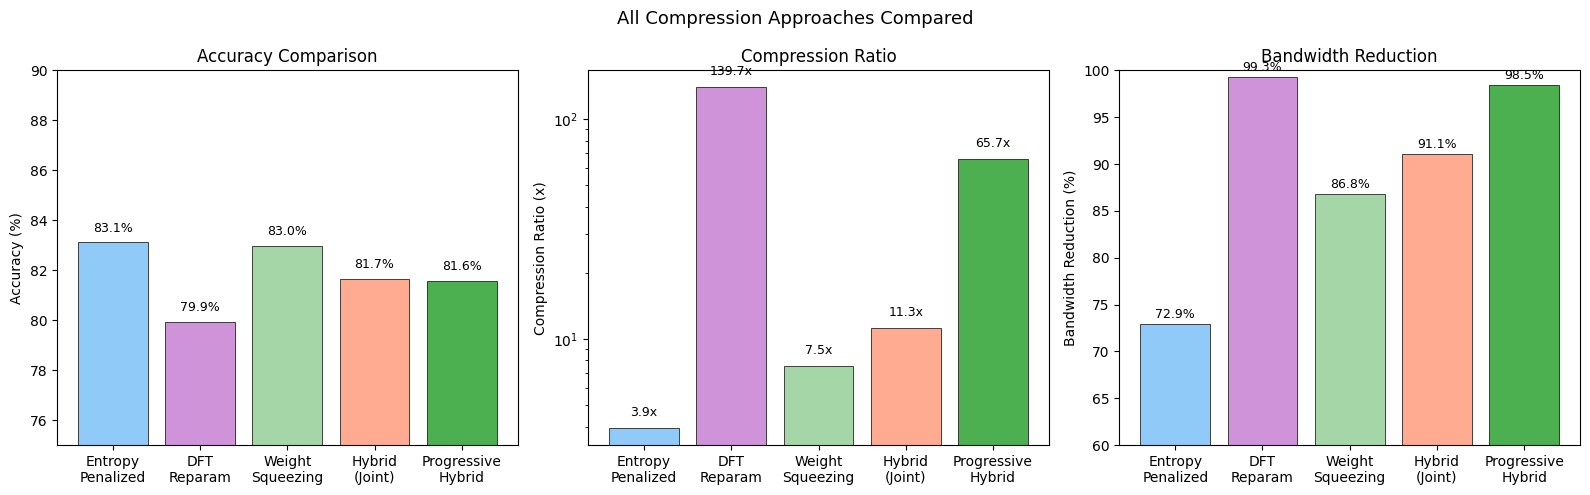

In [16]:
# Comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

short_names = ['Entropy\nPenalized', 'DFT\nReparam', 'Weight\nSqueezing', 'Hybrid\n(Joint)', 'Progressive\nHybrid']
accs = [a[1] for a in approaches]
crs = [a[2] for a in approaches]
bws = [a[3] for a in approaches]

bar_colors = ['#90CAF9', '#CE93D8', '#A5D6A7', '#FFAB91', '#4CAF50']

# Accuracy
ax = axes[0]
bars = ax.bar(short_names, accs, color=bar_colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy Comparison')
ax.set_ylim(75, 90)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=9)

# Compression ratio (log scale)
ax = axes[1]
bars = ax.bar(short_names, crs, color=bar_colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Compression Ratio (x)')
ax.set_title('Compression Ratio')
ax.set_yscale('log')
for bar, val in zip(bars, crs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1, f'{val:.1f}x',
            ha='center', va='bottom', fontsize=9)

# Bandwidth reduction
ax = axes[2]
bars = ax.bar(short_names, bws, color=bar_colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Bandwidth Reduction (%)')
ax.set_title('Bandwidth Reduction')
ax.set_ylim(60, 100)
for bar, val in zip(bars, bws):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=9)

plt.suptitle('All Compression Approaches Compared', fontsize=13)
plt.tight_layout()
plt.savefig('progressive_hybrid_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Save Results

In [17]:
results = {
    'method': 'Progressive_Hybrid_Compression',
    'techniques': [
        'Phase 1: Weight Squeezing + Multi-Teacher KD',
        'Phase 2: + Gradual Structured Pruning',
        'Phase 3: + 4-bit Quantization-Aware Training'
    ],
    'final_accuracy': float(final_acc),
    'final_loss': float(final_loss),
    'compression_ratio': float(final_stats['compression_ratio']),
    'bandwidth_reduction': float(final_stats['bandwidth_reduction']),
    'bits_per_param': float(final_stats['bits_per_param']),
    'teacher_params': int(final_stats['teacher_params']),
    'student_active_params': int(final_stats['student_active_params']),
    'config': {
        'phase1_rounds': PHASE1_ROUNDS,
        'phase2_rounds': PHASE2_ROUNDS,
        'phase3_rounds': PHASE3_ROUNDS,
        'temperature': TEMPERATURE,
        'alpha_kd': ALPHA_KD,
        'pruning_end_sparsity': PRUNING_END_SPARSITY,
        'lambda_pruning': LAMBDA_PRUNING,
        'quantization_bits': QUANTIZATION_BITS,
        'qat_learning_rate': QAT_LEARNING_RATE
    },
    'comparison': {
        'entropy_penalized': {'accuracy': 83.11, 'compression': 3.94, 'bandwidth': 72.9},
        'dft_reparameterization': {'accuracy': 79.93, 'compression': 139.66, 'bandwidth': 99.3},
        'weight_squeezing': {'accuracy': 82.97, 'compression': 7.55, 'bandwidth': 86.8},
        'hybrid_joint': {'accuracy': 81.66, 'compression': 11.28, 'bandwidth': 91.1},
        'progressive_hybrid': {
            'accuracy': float(final_acc * 100),
            'compression': float(final_stats['compression_ratio']),
            'bandwidth': float(final_stats['bandwidth_reduction'])
        }
    },
    'history': {
        'round': history['round'],
        'loss': [float(x) for x in history['loss']],
        'accuracy': [float(x) for x in history['accuracy']],
        'compression_ratio': [float(x) for x in history['compression_ratio']],
        'bandwidth_reduction': [float(x) for x in history['bandwidth_reduction']],
        'bits_per_param': [float(x) for x in history['bits_per_param']],
        'phase': history['phase'],
        'sparsity': [float(x) for x in history['sparsity']]
    }
}

with open('progressive_hybrid_results.json', 'w') as f:
    json.dump(results, f, indent=2)

global_model.save_weights('progressive_hybrid_weights.weights.h5')

print("Results saved:")
print("  - progressive_hybrid_results.json")
print("  - progressive_hybrid_weights.weights.h5")
print("  - progressive_hybrid_results.png")
print("  - progressive_hybrid_comparison.png")

Results saved:
  - progressive_hybrid_results.json
  - progressive_hybrid_weights.weights.h5
  - progressive_hybrid_results.png
  - progressive_hybrid_comparison.png
